# Course: Modern Methods of Data Analysis.

## Homework 1. Topic: Basic classification techniques. Quality metric and cross-validation.

***Author: Ivan Zaputliaev (former TA)***  

---

**Lecturer:** Dmitry Ignatov [dmitrii.ignatov@gmail.com](dmitrii.ignatov@gmail.com)

**TAs:** Anastasia Nasykhova [nasykhova18122002@gmail.com](nasykhova18122002@gmail.com), Faiasal Baber [faisalbaberfbs@gmail.com](dvpozdnyakov@hse.ru), Wei Yuan [zuoxu3310@gmail.com](zuoxu3310@gmail.com), and Denis Pozdnyakov [dvpozdnyakov@hse.ru](dvpozdnyakov@hse.ru)

**Q&A:** course chat ([link](https://t.me/+RQPijCw1QJg2NzZi)) or via TA's e-mail


**Released on** <span style="color:green">***April 14***</span>

**Soft deadline** (up to 10 points): <span style="color:red">***April 26***</span>   

**Hard deadline** (-2 points):  <span style="color:blue">***April 28***</span>    


---



 
Please send your final notebooks to both teaching assistants (and lecturer in CC) with the **mandatory topic** ***[MMDA2026-HW1-Classification-your_full_name]***.

*The dataset source: UCI ML repository (https://archive.ics.uci.edu/ml/datasets)*


In [1]:
import sys

sys.version

'3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]'

In [2]:
# noinspection PyUnusedLocal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler, Normalizer, MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

# extended methods
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

sns.set_style('whitegrid')
%matplotlib inline

## Binary classification

### Load data

In [3]:
train = pd.read_csv('spambase_train.csv', sep=',')
test = pd.read_csv('spambase_test.csv', sep=',')
target = 'is_spam'

x_dev, y_dev = train.drop(target, axis=1), train[target]
x_test, y_test = test.drop(target, axis=1), test[target]

train.head(10)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.05,0.00,0.45,0.0,0.15,0.1,0.00,0.00,0.55,0.00,...,0.203,0.195,0.050,0.000,0.014,0.000,2.880,45,1080,0
1,0.17,0.26,1.21,0.0,0.43,0.6,0.43,0.26,0.69,0.52,...,0.000,0.108,0.000,0.271,0.243,0.013,6.395,583,1375,1
2,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.153,0.000,0.000,1.933,7,58,0
3,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,4.333,20,26,0
4,0.00,0.56,0.00,0.0,0.56,0.0,0.00,0.00,1.01,0.56,...,0.000,0.186,0.000,0.056,0.056,0.000,2.153,53,532,1
5,0.00,0.00,2.25,0.0,0.00,0.0,0.00,0.00,0.00,0.00,...,0.000,0.369,0.000,0.000,0.000,0.000,2.032,10,63,0
6,0.00,0.00,0.00,0.0,0.00,0.0,0.00,1.05,0.00,0.00,...,0.000,0.000,0.000,0.702,0.263,0.000,6.487,47,266,1
7,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.40,0.00,0.00,...,0.126,0.063,0.063,0.063,0.000,0.000,1.611,12,116,0
8,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,...,0.000,0.228,0.000,0.000,0.000,0.000,1.000,1,12,0
9,0.00,0.00,0.00,0.0,0.10,0.0,0.00,0.00,0.00,0.00,...,0.140,0.500,0.093,0.000,0.000,0.000,4.060,51,1003,0


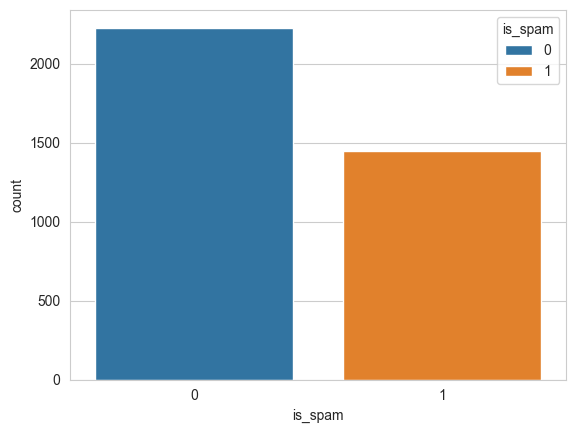

In [4]:
_ = sns.countplot(x=y_dev, hue=y_dev)

### Perform cross-validation to train Logistic Regression

Set cross-validation parameters

In [5]:
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1)

Set data scaling parameters

In [6]:
scaler = StandardScaler()

Set classifier parameters

In [7]:
clf_params = {'penalty': 'l2', 'C': 0.001}
clf = LogisticRegression(**clf_params, solver='lbfgs', n_jobs=8, random_state=1)

Perform cross-validation to calculate model's quality. Draw the ROC-curve to detect overfitting


fold 1 of 5:
   accuracy  roc_auc_score  f1_score  precision_score  recall_score
0  0.860054       0.949397   0.79922         0.919283      0.706897

fold 2 of 5:
   accuracy  roc_auc_score  f1_score  precision_score  recall_score
0  0.865489        0.95109  0.807018         0.928251      0.713793

fold 3 of 5:
   accuracy  roc_auc_score  f1_score  precision_score  recall_score
0  0.872283       0.949497  0.819923         0.922414      0.737931

fold 4 of 5:
   accuracy  roc_auc_score  f1_score  precision_score  recall_score
0  0.877717       0.947116  0.828244          0.92735      0.748276

fold 5 of 5:
   accuracy  roc_auc_score  f1_score  precision_score  recall_score
0  0.870924       0.946954   0.81336         0.945205      0.713793


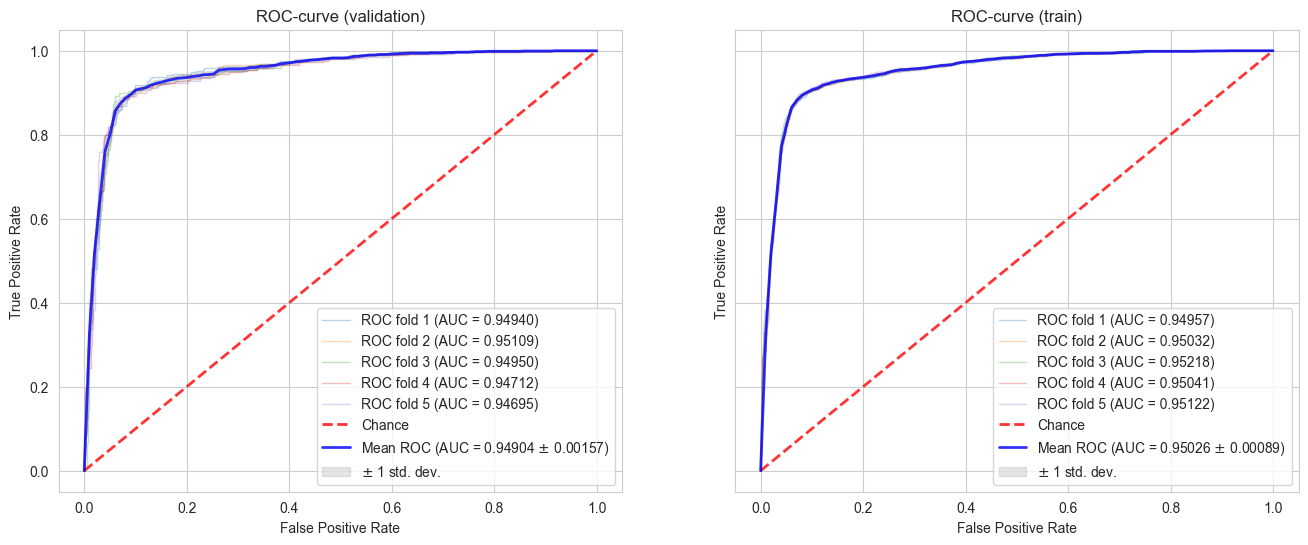

In [8]:
models = []

tprs = [[], []]
aucs = [[], []]
mean_fpr = np.linspace(0, 1, 100)
i = 1

fig, ax = plt.subplots(ncols=2, sharey=True)
fig.set_size_inches(16, 6)

for index_train, index_val in cv.split(X=x_dev, y=y_dev):
    # split data to train/validation
    x_train, y_train = x_dev.loc[index_train].values, y_dev.loc[index_train].values
    x_val, y_val = x_dev.loc[index_val].values, y_dev.loc[index_val].values

    # data scaling for metric classifiers
    x_train_scaled = scaler.fit_transform(x_train)
    x_val_scaled = scaler.transform(x_val)

    # train model
    model = clf.fit(x_train_scaled, y_train)
    models.append(model)  # save trained models

    # make prediction and calculate model's quality
    y_val_pred = model.predict(x_val_scaled)  # predicted labels
    y_val_pred_proba = model.predict_proba(x_val_scaled)[:, 1]  # predicted probability of being from class 1

    y_val_pred_quality = pd.DataFrame({'accuracy': accuracy_score(y_val, y_val_pred),
                                       'roc_auc_score': roc_auc_score(y_val, y_val_pred_proba),
                                       'f1_score': f1_score(y_val, y_val_pred),
                                       'precision_score': precision_score(y_val, y_val_pred),
                                       'recall_score': recall_score(y_val, y_val_pred)}, index=[0])
    print()
    print(f'fold {i:d} of {n_splits:d}:')
    print(y_val_pred_quality)

    # calculate ROC-AUC
    # validation
    fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
    tprs[0].append(np.interp(mean_fpr, fpr, tpr))
    tprs[0][-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs[0].append(roc_auc)
    _ = ax[0].plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i:d} (AUC = {roc_auc:0.5f})')

    # train 
    fpr, tpr, thresholds = roc_curve(y_train, model.predict_proba(x_train_scaled)[:, 1])
    tprs[1].append(np.interp(mean_fpr, fpr, tpr))
    tprs[1][-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs[1].append(roc_auc)
    _ = ax[1].plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i:d} (AUC = {roc_auc:0.5f})')

    i += 1

# plot ROC-curve
for i in range(2):
    _ = ax[i].plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)

    mean_tpr = np.mean(tprs[i], axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs[i])
    _ = ax[i].plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:0.5f} $\pm$ {std_auc:0.5f})', lw=2,
                   alpha=.8)

    std_tpr = np.std(tprs[i], axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    _ = ax[i].fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')

    _ = ax[i].set_xlim([-0.05, 1.05])
    _ = ax[i].set_ylim([-0.05, 1.05])
    _ = ax[i].set_xlabel('False Positive Rate')
    _ = ax[i].set_ylabel('True Positive Rate')
    _ = ax[i].legend(loc='lower right')

_ = ax[0].set_title('ROC-curve (validation)')
_ = ax[1].set_title('ROC-curve (train)')
plt.show()

Look at LR coefficients and analyse results

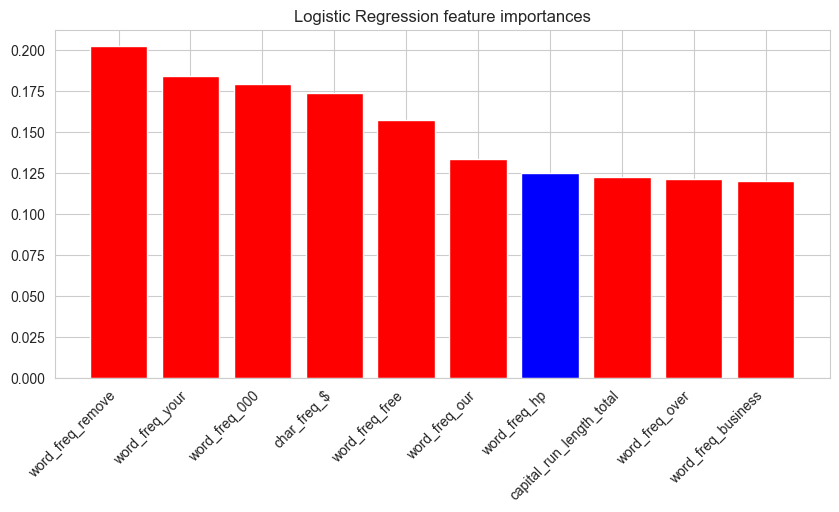

In [9]:
i = 0
lr_feature_importance = pd.DataFrame({'feature': x_dev.columns,
                                      'coeff': models[i].coef_[0], 'abs(coeff)': np.abs(models[i].coef_[0])})
lr_feature_importance.sort_values('abs(coeff)', ascending=False).head(10)

coefs = lr_feature_importance['coeff'].values
color = np.array(['red' if c > 0 else 'blue' for c in coefs])
coefs = np.abs(coefs)
indices = np.argsort(coefs)[::-1]

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
plt.title('Logistic Regression feature importances')
plt.bar(range(10), coefs[indices[:10]], color=color[indices[:10]], align='center')
plt.xticks(range(10), x_dev.columns[indices[:10]], rotation=45, ha='right')
plt.subplots_adjust(bottom=0.3)
plt.show()

Plot probabilities distribution for the validation data from last CV iteration of being from "spam" class

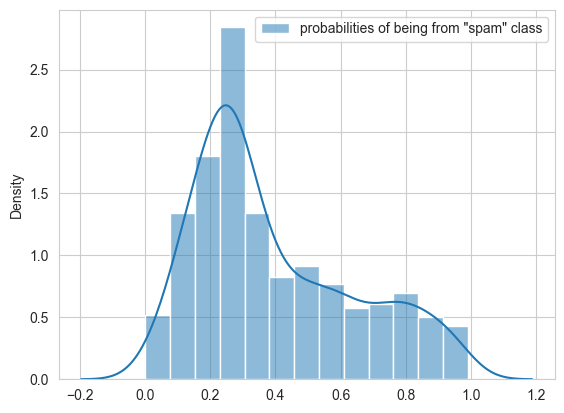

In [10]:
model = models[-1]
y_val_pred_proba = model.predict_proba(x_val_scaled)[:, 1]

_ = sns.histplot(y_val_pred_proba, kde=True, stat='density', kde_kws=dict(cut=3),
                 label='probabilities of being from "spam" class')
_ = plt.legend()
plt.show()

Show confusion matrix for LR prediction

Confusion matrix:
[[434  12]
 [ 83 207]]


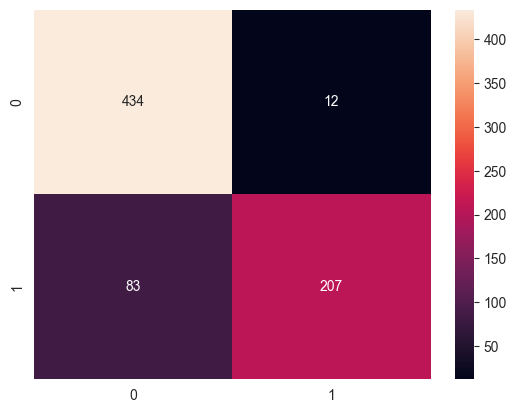

In [11]:
y_val_pred = model.predict(x_val_scaled)
print('Confusion matrix:')
confusion_matrix_df = confusion_matrix(y_val, y_val_pred)
print(confusion_matrix_df)
_ = sns.heatmap(confusion_matrix_df, annot=True, fmt='.10g')

---
### Task 1 (3 points)

In [12]:
METRICS = ["accuracy", "roc_auc_score", "f1_score", "precision_score", "recall_score"]

def quality_metrics(
    y_true: np.ndarray, y_pred_proba: np.ndarray, prefix: str, with_confusion: bool = False
) -> dict:
    y_pred = (y_pred_proba > 0.5).astype(int)
    metrics = {
        f'{prefix}_accuracy': accuracy_score(y_true, y_pred),
        f'{prefix}_roc_auc_score': roc_auc_score(y_true, y_pred_proba),
        f'{prefix}_f1_score': f1_score(y_true, y_pred),
        f'{prefix}_precision_score': precision_score(y_true, y_pred),
        f'{prefix}_recall_score': recall_score(y_true, y_pred)
    }
    if with_confusion:
        metrics[f'{prefix}_confusion'] =  confusion_matrix(y_true, y_pred)
    return metrics

#### Part 1

Try 3 different values of n_splits and analyse overfitting and stability

Find n_splits values with maximum and minimum overfitting

Find n_splits values with maximum and minimum stability

In [13]:
def try_n_splits(n_splits: int, *args, scale: bool):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    results = []
    for index_train, index_val in cv.split(X=x_dev, y=y_dev):
        x_train, y_train = x_dev.loc[index_train].values, y_dev.loc[index_train].values
        x_val, y_val = x_dev.loc[index_val].values, y_dev.loc[index_val].values

        if scale:
            scaler = StandardScaler()
            x_train = scaler.fit_transform(x_train)
            x_val = scaler.transform(x_val)

        clf = LogisticRegression(penalty='l2', C=0.001, solver='lbfgs', n_jobs=-1, random_state=42)
        clf = clf.fit(x_train, y_train)
        results.append({
            **quality_metrics(y_train, clf.predict_proba(x_train)[:, 1], 'train'),
            **quality_metrics(y_val, clf.predict_proba(x_val)[:, 1], 'val')
        })
    results = pd.DataFrame(results)
    for metric in METRICS:
        results[f"diff_{metric}"] = results[f"train_{metric}"] - results[f"val_{metric}"]
    results.loc["mean"] = results.mean()
    results.loc["std"] = results.std()
    # display(results)

    # Overfitting is measured by the difference between training quality and validation quality
    print(f"Overfitting: ")
    display(pd.DataFrame(results.loc["mean"][[f"diff_{metric}" for metric in METRICS]].to_dict(), index=["mean"]))
    
    # Stability is measured by the deviation of validation quality throughout different folds
    print(f"Stability: ")
    display(pd.DataFrame(results.loc["std"][[f"val_{metric}" for metric in METRICS]].to_dict(), index=["std"]))

In [14]:
for n_splits in [3, 5, 10]:
    print(f"## {n_splits} splits")
    try_n_splits(n_splits, scale=True)

## 3 splits
Overfitting: 


,diff_accuracy,diff_roc_auc_score,diff_f1_score,diff_precision_score,diff_recall_score
mean,0.000819,0.002519,0.001361,0.00155,0.001039


Stability: 


,val_accuracy,val_roc_auc_score,val_f1_score,val_precision_score,val_recall_score
std,0.012372,0.004193,0.020442,0.009329,0.026103


## 5 splits
Overfitting: 


...

,val_accuracy,val_roc_auc_score,val_f1_score,val_precision_score,val_recall_score
std,0.010615,0.004471,0.017706,0.009037,0.025189


## 10 splits
Overfitting: 


,diff_accuracy,diff_roc_auc_score,diff_f1_score,diff_precision_score,diff_recall_score
mean,0.001359,0.001525,0.002492,0.000388,0.003295


Stability: 


,val_accuracy,val_roc_auc_score,val_f1_score,val_precision_score,val_recall_score
std,0.013337,0.008082,0.021225,0.016476,0.029227


The most overfitting happens with `n_splits=5`, the least overfitting is for `n_splits=3`.

In terms of stability, `n_splits=5` shows the best results, and `n_splits=10` is the worst one. Expectedly, small `n_splits` provide too little data for training, while too big `n_splits`, on the other hand, leave only a few examples for validation.

#### Part 2

Compare different values of Logistic Regression hyperparameters using cross-validation. 

Try different values for: penalty, C, class_weight

Find the best parameters according to F1-score

In [15]:
def get_best_lr(*args, scale: bool, scoring: str = 'f1'):
    penalty = ['l1', 'l2']
    C = [1.0, 10.0, 0.01, 0.001]
    class_weight = ['balanced', None]
    param_grid = {'lr__penalty': penalty, 'lr__C': C, 'lr__class_weight': class_weight}

    pipeline = []
    if scale:
        pipeline.append(('scaler', StandardScaler()))
    pipeline.append(('lr', LogisticRegression(solver='saga', max_iter=10000, random_state=42)))

    cv = StratifiedKFold(5, shuffle=True, random_state=42)
    search = GridSearchCV(Pipeline(pipeline), param_grid, scoring=scoring, cv=cv, n_jobs=-1)
    search = search.fit(x_dev.values, y_dev.values)
    print(f"Best F1 = {search.best_score_:.4f}, params: {search.best_params_}")

    return {
        key[len("lr__"):]: value
        for key, value in search.best_params_.items()
    }

In [16]:
best_params = get_best_lr(scale=True)

Best F1 = 0.9087, params: {'lr__C': 1.0, 'lr__class_weight': 'balanced', 'lr__penalty': 'l1'}


#### Part 3

Train a model with the best parameters on the whole training dataset.

Analyse overfitting using the test data. Is it lower or bigger, comparing to validation case?

In [17]:
def run_lr(params: dict, *args, scale: bool):
    x_train, x_testing = x_dev, x_test
    if scale:
        scaler = StandardScaler()
        x_train = scaler.fit_transform(x_train)
        x_testing = scaler.transform(x_testing)

    clf = LogisticRegression(**params, solver='saga', max_iter=10000, random_state=42)
    clf = clf.fit(x_train, y_dev)
    display({
        **quality_metrics(y_dev, clf.predict_proba(x_train)[:, 1], 'dev'),
        **quality_metrics(y_test, clf.predict_proba(x_testing)[:, 1], 'test')
    })
    return clf

In [18]:
clf = run_lr(best_params, scale=True)

{'dev_accuracy': 0.9334239130434783,
 'dev_roc_auc_score': 0.9768348538735118,
 'dev_f1_score': 0.9161820047895998,
 'dev_precision_score': 0.9090291921249152,
 'dev_recall_score': 0.923448275862069,
 'test_accuracy': 0.9218241042345277,
 'test_roc_auc_score': 0.9709015867373639,
 'test_f1_score': 0.9024390243902439,
 'test_precision_score': 0.888,
 'test_recall_score': 0.9173553719008265}

F1-score on the test set is 0.902, which is lower than 0.916 on the training set. The difference is not very big, so there might be some level of overfitting, yet it is not very significant.

F1-score in the validation case was 0.909, indicating less overfitting in that case.

#### Part 4

Find 5 most valuable features for "spam" class and 5 for "not spam" class

In [19]:
def print_most_valuable(clf: LogisticRegression):
    df = pd.DataFrame({'feature': x_dev.columns, 'coeff': clf.coef_[0]})
    df = df.sort_values('coeff')
    
    print('"spam" class')
    display(df.tail(5))
    
    print('"not spam" class')
    display(df.head(5))

In [20]:
print_most_valuable(clf)

"spam" class


,feature,coeff
6,word_freq_remove,0.895935
53,char_freq_#,0.973450
52,char_freq_$,1.456571
54,capital_run_length_average,1.518747
55,capital_run_length_longest,1.597063


"not spam" class


,feature,coeff
26,word_freq_george,-6.410789
24,word_freq_hp,-2.569556
40,word_freq_cs,-2.048471
41,word_freq_meeting,-1.530869
34,word_freq_85,-1.511524


#### Part 5

Find 10 most and 10 least "spam" object in test data and print them

In [21]:
def print_extreme_examples(clf: LogisticRegression, *args, scale: bool):
    x_testing = x_test
    if scale:
        scaler = StandardScaler().fit(x_dev)
        x_testing = scaler.transform(x_testing)
    df = x_test.copy()
    df["is_spam_proba"] = clf.predict_proba(x_testing)[:, 1]
    df["target"] = y_test
    df = df.sort_values(by='is_spam_proba', ascending=False)

    print('Most spam')
    display(df.head(10))
    
    print('Least spam')
    display(df.tail(10))

In [22]:
print_extreme_examples(clf, scale=True)

Most spam


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam_proba,target
481,0.34,0.00,1.70,0.00,1.02,0.00,0.00,0.00,0.68,1.02,...,0.000,0.0,0.902,0.106,0.000,664.000,1327,1328,1.0,1
465,0.38,0.00,1.90,0.00,1.14,0.00,0.00,0.00,0.38,0.38,...,0.000,0.0,1.008,0.059,0.000,295.000,1177,1180,1.0,1
26,0.40,0.40,0.00,0.00,0.00,0.00,0.00,0.00,1.20,4.81,...,0.000,0.0,0.855,0.794,0.000,4.152,41,353,1.0,1
628,0.00,0.00,0.00,40.13,0.00,0.00,0.00,0.00,0.00,0.32,...,0.185,0.0,0.185,0.061,0.000,10.585,124,434,1.0,1
296,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.018,0.0,0.000,0.000,0.000,251.000,1488,1506,1.0,0
881,0.22,0.22,0.22,0.00,1.77,0.22,0.44,0.44,0.22,2.88,...,0.000,0.0,0.563,0.150,0.000,86.650,1038,1733,1.0,1
908,0.00,0.00,1.07,0.00,3.22,0.00,0.00,0.00,0.00,0.00,...,0.000,0.0,2.395,0.598,0.998,82.250,295,329,1.0,1
91,0.00,0.00,0.00,0.00,1.21,0.00,1.21,1.21,1.21,1.21,...,0.000,0.0,0.555,0.000,0.000,104.666,311,314,1.0,1
298,0.29,0.04,0.04,0.00,0.14,0.04,0.00,0.29,0.29,0.94,...,0.053,0.0,0.356,0.090,0.011,12.332,1171,9163,1.0,1
406,0.00,0.29,0.29,0.00,0.00,0.59,0.29,1.04,1.04,2.22,...,0.084,0.0,0.105,0.210,0.021,10.817,887,1244,1.0,1


Least spam


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam_proba,target
459,0.0,0.0,0.0,0.0,5.55,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,1.222,3,11,2.174144e-21,0
37,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,2.333,5,7,5.332086e-22,0
918,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,2.000,4,6,5.207452e-22,0
507,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,1.000,1,4,4.853386e-22,0
843,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,1.000,1,4,4.853386e-22,0
524,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,1.229,0.0,0.0,0.0,0.0,3.250,11,39,1.439542e-22,0
8,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,5.500,10,11,7.117210e-27,0
236,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,5.500,10,11,7.117210e-27,0
17,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.0,0.0,0.0,1.000,1,3,5.721214e-29,0
199,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,1.190,0.0,0.0,0.0,0.0,3.333,11,30,8.641916e-30,0


#### Part 6

How many "spam" object from the test data are not detected by classifier with the best parameters?

How many "not spam" object from the test data are recognized as "spam"?

In [23]:
def print_confusion(clf: LogisticRegression, *args, scale: bool):
    x_testing = x_test
    if scale:
        scaler = StandardScaler().fit(x_dev)
        x_testing = scaler.transform(x_testing)

    display(confusion_matrix(y_test, clf.predict(x_testing)))

In [24]:
print_confusion(clf, scale=True)

array([[516,  42],
       [ 30, 333]], dtype=int64)

> How many "spam" object from the test data are not detected by classifier with the best parameters?

30

> How many "not spam" object from the test data are recognized as "spam"?

42

#### Part 7

Try all previous steps without data scaling
* Show how quality on test data changed
* Show how most valuable features changed
* Show how "spam" and "not spam" objects changed
* Show how probabilities distribution changed

In [25]:
for n_splits in [3, 5, 10]:
    print(f"## {n_splits} splits")
    try_n_splits(n_splits, scale=False)

## 3 splits
Overfitting: 


,diff_accuracy,diff_roc_auc_score,diff_f1_score,diff_precision_score,diff_recall_score
mean,0.004343,0.002448,0.006383,0.005694,0.006888


Stability: 


,val_accuracy,val_roc_auc_score,val_f1_score,val_precision_score,val_recall_score
std,0.00909,0.002705,0.0152,0.011701,0.022584


## 5 splits
Overfitting: 


...

,val_accuracy,val_roc_auc_score,val_f1_score,val_precision_score,val_recall_score
std,0.017569,0.009195,0.028733,0.015393,0.037177


## 10 splits
Overfitting: 


,diff_accuracy,diff_roc_auc_score,diff_f1_score,diff_precision_score,diff_recall_score
mean,0.00465,0.000737,0.008361,0.000679,0.012567


Stability: 


,val_accuracy,val_roc_auc_score,val_f1_score,val_precision_score,val_recall_score
std,0.015239,0.012248,0.02366,0.025126,0.031971


In [26]:
best_params = get_best_lr(scale=False)

Best F1 = 0.7971, params: {'lr__C': 1.0, 'lr__class_weight': None, 'lr__penalty': 'l1'}


In [27]:
clf = run_lr(best_params, scale=False)

{'dev_accuracy': 0.8171195652173913,
 'dev_roc_auc_score': 0.8893244162672026,
 'dev_f1_score': 0.7958750379132544,
 'dev_precision_score': 0.7103410936654033,
 'dev_recall_score': 0.9048275862068965,
 'test_accuracy': 0.8045602605863192,
 'test_roc_auc_score': 0.8710763549473227,
 'test_f1_score': 0.7831325301204819,
 'test_precision_score': 0.69593147751606,
 'test_recall_score': 0.8953168044077136}

The quality is much lower. Without scaling, we lost about 0.12 F1-score, yet we still have the same overfitting patterns as before.

In [28]:
print_most_valuable(clf)

"spam" class


,feature,coeff
51,char_freq_!,0.008326
6,word_freq_remove,0.008502
55,capital_run_length_longest,0.011939
15,word_freq_free,0.012374
20,word_freq_your,0.015019


"not spam" class


,feature,coeff
26,word_freq_george,-0.064088
24,word_freq_hp,-0.057214
25,word_freq_hpl,-0.027921
44,word_freq_re,-0.023390
54,capital_run_length_average,-0.020398


Expectedly, the sets of most valuable features changed. Although some features (e.g. `word_freq_george`) remained in their positions, others changed completely. This indicates that some features in the dataset overwhelm other ones by mere scale.

In [29]:
print_extreme_examples(clf, scale=False)

Most spam


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam_proba,target
557,0.35,0.08,0.35,0.0,0.35,0.00,0.00,0.52,0.61,1.76,...,0.081,0.0,0.556,0.069,0.011,19.234,1170,3116,0.999997,1
296,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.018,0.0,0.000,0.000,0.000,251.000,1488,1506,0.999995,0
298,0.29,0.04,0.04,0.0,0.14,0.04,0.00,0.29,0.29,0.94,...,0.053,0.0,0.356,0.090,0.011,12.332,1171,9163,0.999990,1
881,0.22,0.22,0.22,0.0,1.77,0.22,0.44,0.44,0.22,2.88,...,0.000,0.0,0.563,0.150,0.000,86.650,1038,1733,0.999963,1
406,0.00,0.29,0.29,0.0,0.00,0.59,0.29,1.04,1.04,2.22,...,0.084,0.0,0.105,0.210,0.021,10.817,887,1244,0.999956,1
509,0.50,0.43,0.28,0.0,0.14,0.03,0.00,0.18,0.54,0.61,...,0.078,0.0,0.439,0.505,0.132,6.683,798,2426,0.999842,1
253,0.59,0.44,0.29,0.0,0.14,0.03,0.03,0.14,0.56,0.67,...,0.075,0.0,0.613,0.532,0.137,7.300,763,2453,0.999755,1
465,0.38,0.00,1.90,0.0,1.14,0.00,0.00,0.00,0.38,0.38,...,0.000,0.0,1.008,0.059,0.000,295.000,1177,1180,0.999549,1
847,0.16,0.24,1.23,0.0,0.41,0.57,0.49,0.32,0.65,0.49,...,0.114,0.0,0.241,0.228,0.012,6.544,683,1466,0.999513,1
477,0.31,0.20,0.72,0.0,0.00,0.62,0.00,0.62,0.62,0.93,...,0.000,0.0,0.548,0.199,0.033,14.283,685,1514,0.999440,1


Least spam


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam_proba,target
899,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.000,1,5,0.209809,0
252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.000,1,5,0.209809,0
797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.000,1,5,0.209809,0
35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.000,1,5,0.209809,0
722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.000,1,5,0.209809,0
37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.333,5,7,0.164319,0
918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.000,4,6,0.163647,0
843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.000,1,4,0.161613,0
507,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.000,1,4,0.161613,0
17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.000,1,3,0.101572,0


The probability distribution is different. Previously, the most spam objects had a score of 1.0, and the least spam objects - almost zero ($10^{-20}$ and less). Now, there are no objects with score 1.0, and the least spammy object has a relatively big score of 0.1

In [30]:
print_confusion(clf, scale=False)

array([[416, 142],
       [ 38, 325]], dtype=int64)

Expectedly, there are more mistakes now; especially Type I ones (false positive). Almost 142 objects have been wrongly marked as "spam".

---
### Perform GridSearchCV to train Naive Bayes classifier

In [31]:
# set data scaler
scaler = MinMaxScaler((0, 1))

# set classifier parameters
clf_params = {'alpha': np.linspace(0, 1, 10),
              'fit_prior': [True, False]}
clf = MultinomialNB()

# set scorer
scorer_ = 'f1'

# set CV parameters
cv = 5

# set GridSearch parameters
grcv = GridSearchCV(estimator=clf, param_grid=clf_params, scoring=scorer_, cv=cv, return_train_score=True, n_jobs=8,
                    verbose=1)

# set Pipeline parameters
pipeline = Pipeline(steps=[('scaling', scaler), ('parameters tuning', grcv)])

# launch pipeline with scaling followed by cross-validation with parameters tuning
_ = pipeline.fit(x_dev.values, y_dev.values)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


### Find the best NB parameters

In [32]:
print(f'NB classifier gets best {str(scorer_)}: {grcv.best_score_:f} with parameters: {str(grcv.best_params_)}')

NB classifier gets best f1: 0.853624 with parameters: {'alpha': 0.1111111111111111, 'fit_prior': True}


### Look at GridSearchCV history

In [33]:
columns_to_drop = ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'params']
grcv_result = pd.DataFrame(grcv.cv_results_).drop(columns_to_drop, axis=1)
grcv_result.head(10)

,param_alpha,param_fit_prior,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.000000,True,0.869725,0.854962,0.860294,0.579739,0.858779,0.804700,0.112585,19,0.854333,0.855545,0.858080,0.576111,0.854079,0.799630,0.111768
1,0.000000,False,0.844175,0.836090,0.824588,0.579739,0.834862,0.783891,0.102266,20,0.825792,0.835424,0.833144,0.576111,0.834026,0.780900,0.102448
2,0.111111,True,0.863469,0.854962,0.858195,0.832714,0.858779,0.853624,0.010802,1,0.853121,0.855545,0.858614,0.867627,0.853545,0.857690,0.005334
3,0.111111,False,0.844175,0.833583,0.820896,0.819820,0.834862,0.830667,0.009184,10,0.825743,0.833649,0.831257,0.832457,0.830260,0.830673,0.002715
4,0.222222,True,0.863469,0.854962,0.859779,0.830540,0.858779,0.853506,0.011798,2,0.850564,0.853408,0.857143,0.865394,0.849930,0.855288,0.005659
5,0.222222,False,0.842900,0.831091,0.819672,0.819820,0.834862,0.829669,0.008956,11,0.823883,0.833460,0.830445,0.830274,0.829012,0.829414,0.003128
6,0.333333,True,0.863469,0.854962,0.859779,0.830540,0.858779,0.853506,0.011798,2,0.850564,0.853271,0.856071,0.865394,0.849930,0.855046,0.005613
7,0.333333,False,0.842900,0.827381,0.819672,0.819820,0.833588,0.828672,0.008805,12,0.822647,0.833585,0.830132,0.828721,0.828207,0.828659,0.003544
8,0.444444,True,0.863469,0.854962,0.859779,0.830540,0.856597,0.853069,0.011634,4,0.848542,0.853670,0.854597,0.865394,0.849533,0.854347,0.005990
9,0.444444,False,0.839098,0.826152,0.819672,0.818591,0.832317,0.827166,0.007741,13,0.822472,0.832012,0.828518,0.827921,0.827715,0.827728,0.003054


### Task 2 (2 points)

#### Part 1

Find 5 best parameters' combinations for trained GridSearchCV

Show Naive Bayes quality with these parameters

In [34]:
def try_cv(scorer, *args, with_worst: bool = False):
    params = { 'alpha': np.linspace(0, 1, 11), 'fit_prior': [True, False] }
    clf = MultinomialNB()
    search = GridSearchCV(
        estimator=clf, param_grid=params, scoring=scorer, cv=5, return_train_score=True, n_jobs=-1
    )
    pipeline = Pipeline([('scaling', MinMaxScaler((0, 1))), ('nb', search)])
    pipeline = pipeline.fit(x_dev, y_dev)

    report = []
    for _, row in pd.DataFrame(search.cv_results_).sort_values(by='rank_test_score').iterrows():
        pipeline = Pipeline([('scaling', MinMaxScaler((0, 1))), ('nb', MultinomialNB(**row['params']))])
        pipeline = pipeline.fit(x_dev, y_dev)
        report.append({
            **row['params'],
            'mean_cv_score': row['mean_test_score'],
            **quality_metrics(y_test, pipeline.predict_proba(x_test)[:, 1], "test")
        })

    display(pd.DataFrame(report).head(5))
    if with_worst:
        display(pd.DataFrame(report).tail(5))

In [35]:
try_cv('f1')

,alpha,fit_prior,mean_cv_score,test_accuracy,test_roc_auc_score,test_f1_score,test_precision_score,test_recall_score
0,0.1,True,0.853934,0.896851,0.962227,0.858841,0.932258,0.796143
1,0.2,True,0.853506,0.897937,0.962203,0.860534,0.932476,0.798898
2,0.3,True,0.853506,0.899023,0.961995,0.861813,0.935484,0.798898
3,0.4,True,0.853069,0.897937,0.961857,0.860119,0.935275,0.796143
4,0.7,True,0.852662,0.896851,0.961467,0.858420,0.935065,0.793388


#### Part 2

Set scorer to roc_auc and repeat experiment

Find 5 best parameters' combinations and show NB quality with this parameters

In [36]:
try_cv('roc_auc')

d:\Programs\Programming\Python\lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [       nan        nan 0.95642802 0.95642802 0.9560801  0.9560801
 0.95578011 0.95578011 0.95562548 0.95562548 0.95547394 0.95547394
 0.95533942 0.95533942 0.95522035 0.95522035 0.95509974 0.95509974
 0.95494665 0.95494665 0.95482604 0.95482604]
  warnings.warn(
d:\Programs\Programming\Python\lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the train scores are non-finite: [       nan        nan 0.95755349 0.95755349 0.95722944 0.95722944
 0.95699382 0.95699382 0.95679406 0.95679406 0.95662561 0.95662561
 0.95647011 0.95647011 0.95630591 0.95630591 0.95616152 0.95616152
 0.95604052 0.95604052 0.95591199 0.95591199]
  warnings.warn(


,alpha,fit_prior,mean_cv_score,test_accuracy,test_roc_auc_score,test_f1_score,test_precision_score,test_recall_score
0,0.1,True,0.956428,0.896851,0.962227,0.858841,0.932258,0.796143
1,0.1,False,0.956428,0.853420,0.962227,0.837153,0.744635,0.955923
2,0.2,True,0.956080,0.897937,0.962203,0.860534,0.932476,0.798898
3,0.2,False,0.956080,0.853420,0.962203,0.837935,0.742553,0.961433
4,0.3,True,0.955780,0.899023,0.961995,0.861813,0.935484,0.798898


#### Part 3

Create a custom scorer using make_scorer and repeat the experiment. Note: errors_score is an error metric

Show F1 and roc_auc values for 5 best and 5 worst parameters combinations

In [37]:
def errors_score(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

try_cv(make_scorer(errors_score, greater_is_better=False), with_worst=True)

,alpha,fit_prior,mean_cv_score,test_accuracy,test_roc_auc_score,test_f1_score,test_precision_score,test_recall_score
0,0.1,True,-0.105978,0.896851,0.962227,0.858841,0.932258,0.796143
1,0.2,True,-0.106250,0.897937,0.962203,0.860534,0.932476,0.798898
2,0.3,True,-0.106250,0.899023,0.961995,0.861813,0.935484,0.798898
3,0.4,True,-0.106522,0.897937,0.961857,0.860119,0.935275,0.796143
4,0.5,True,-0.106793,0.897937,0.961724,0.860119,0.935275,0.796143


,alpha,fit_prior,mean_cv_score,test_accuracy,test_roc_auc_score,test_f1_score,test_precision_score,test_recall_score
17,0.8,False,-0.158424,0.847991,0.961344,0.832936,0.734737,0.961433
18,0.9,False,-0.159511,0.847991,0.961250,0.832936,0.734737,0.961433
19,1.0,False,-0.160326,0.849077,0.961191,0.834327,0.735294,0.964187
20,0.0,True,-0.194565,0.896851,0.962474,0.858841,0.932258,0.796143
21,0.0,False,-0.232609,0.856678,0.962474,0.840194,0.749460,0.955923


#### Part 4

Find 5 most valuable features for "spam" class and 5 for "not spam" class

Are these features the same as in LR?

In [38]:
pipeline = Pipeline([('scaling', MinMaxScaler((0, 1))), ('nb', MultinomialNB(alpha=0.1, fit_prior=True))])
pipeline = pipeline.fit(x_dev, y_dev)

# There is no 'coef_' in modern scikit-learn,
# since naive bayes classifier does not have coefficients in the traditional sense
df = pd.DataFrame({
    'feature': x_dev.columns,
    'not_spam_prob': pipeline[1].feature_log_prob_[0],
    'spam_prob': pipeline[1].feature_log_prob_[1]
})
df["diff_prob"] = df["spam_prob"] - df["not_spam_prob"]
df = df.sort_values(by='diff_prob', ascending=True)

print('"spam" class')
display(df.tail(5))

print('"not spam" class')
display(df.head(5))

"spam" class


,feature,not_spam_prob,spam_prob,diff_prob
14,word_freq_addresses,-5.885621,-3.383003,2.502617
19,word_freq_credit,-7.525799,-4.551003,2.974795
6,word_freq_remove,-6.379709,-3.391640,2.988069
22,word_freq_000,-6.441477,-3.206743,3.234734
3,word_freq_3d,-9.368275,-5.611857,3.756418


"not spam" class


,feature,not_spam_prob,spam_prob,diff_prob
26,word_freq_george,-3.065165,-9.133265,-6.068099
28,word_freq_lab,-4.252233,-9.311370,-5.059137
40,word_freq_cs,-4.590328,-9.583888,-4.993560
31,word_freq_857,-3.881248,-8.624792,-4.743544
33,word_freq_415,-3.873740,-8.556553,-4.682813


Some features correlate with the results for LR (e.g. `word_freq_george`). Yet, most features are different.

### Find the best scaler and parameters for k-Nearest Neighbors classifier

In [39]:
# set classifier parameters
clf_params = {'n_neighbors': list(range(1, 6)),
              'p': list(range(1, 3))}
clf = KNeighborsClassifier(n_jobs=1)

# set scorer
scorer_ = 'roc_auc'

# set CV parameters
cv = 5

# set GridSearch parameters
grcv = GridSearchCV(estimator=clf, param_grid=clf_params, scoring=scorer_, cv=cv, return_train_score=True, n_jobs=8,
                    verbose=1)

# set scaler as Pipeline parameter
scaler = Normalizer()

# set Pipeline parameters
pipeline = Pipeline(steps=[('scaling', scaler), ('parameters tuning', grcv)])

# launch the pipeline with scaling followed by cross-validation with parameters tuning
_ = pipeline.fit(x_dev.values, y_dev.values)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


Find best kNN parameters

In [40]:
print(f'kNN classifier gets best {str(scorer_)}: {grcv.best_score_:f} with parameters: {str(grcv.best_params_)}')

kNN classifier gets best roc_auc: 0.920400 with parameters: {'n_neighbors': 5, 'p': 1}


### Task 3 (2 points)

#### Part 1

Try to obtain the best kNN quality using GridSearchCV with different scalers

Print scaler, parameters and obtained quality

In [41]:
def get_best_knn_cv(scoring: str = 'f1'):
    pipeline = Pipeline([ ('scaler', 'passthrough'), ('clf', KNeighborsClassifier()) ])
    param_grid = {
        'scaler': ['passthrough', StandardScaler(), Normalizer(), MinMaxScaler((0, 1))],
        'clf__n_neighbors': list(range(1, 50)),
        'clf__weights': ['uniform', 'distance'],
        'clf__p': [1, 2, np.inf]
    }

    search = GridSearchCV(pipeline, param_grid, scoring=scoring, cv=5, n_jobs=-1)
    return search.fit(x_dev, y_dev)

In [42]:
search = get_best_knn_cv()
print(f"Best F1 = {search.best_score_:.4f}  params: {search.best_params_}")
quality_metrics(y_test, search.best_estimator_.predict_proba(x_test)[:, 1], "test")

Best F1 = 0.8985  params: {'clf__n_neighbors': 12, 'clf__p': 2, 'clf__weights': 'distance', 'scaler': StandardScaler()}


{'test_accuracy': 0.9218241042345277,
 'test_roc_auc_score': 0.9706226487751414,
 'test_f1_score': 0.9,
 'test_precision_score': 0.907563025210084,
 'test_recall_score': 0.8925619834710744}

#### Part 2

Show how kNN quality changes without scaling before training

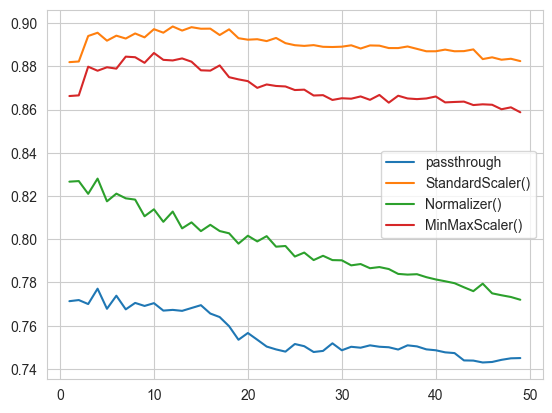

In [43]:
df = pd.DataFrame(search.cv_results_)
df = df[(df["param_clf__p"] == 2) & (df['param_clf__weights'] == 'distance')]

for scaler in df["param_scaler"].unique():
    data = df[(df["param_scaler"].astype(str) == str(scaler))]
    plt.plot(data["param_clf__n_neighbors"], data["mean_test_score"], label=scaler)
plt.legend()

Expectedly, without scaling, kNN shows much worse quality.

### Task 4 (3 points)

#### Part 1

Take the best LR, NB and kNN classifiers according to roc_auc on cross-validation.

Compare their quality on the test data.

Which classifier has the best roc_auc score? What are its parameters?

Which classifier has the least false negatives?

Which classifier has the least type-1 errors?

In [44]:
best_lr = LogisticRegression(
    **get_best_lr(scale=True, scoring='roc_auc'),
    solver='saga',
    max_iter=10000,
    random_state=42
)
best_nb = MultinomialNB(alpha=0.1, fit_prior=True)
best_knn = KNeighborsClassifier(**get_best_knn_cv('roc_auc').best_estimator_.named_steps['clf'].get_params())

print(best_lr)
print(best_nb)
print(best_knn)

Best F1 = 0.9712, params: {'lr__C': 10.0, 'lr__class_weight': 'balanced', 'lr__penalty': 'l1'}
LogisticRegression(C=10.0, class_weight='balanced', max_iter=10000,
                   penalty='l1', random_state=42, solver='saga')
MultinomialNB(alpha=0.1)
KNeighborsClassifier(n_neighbors=21, p=1, weights='distance')


d:\Programs\Programming\Python\lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [45]:
ss = StandardScaler()
x_dev_ss = ss.fit_transform(x_dev)
x_test_ss = ss.transform(x_test)

mms = MinMaxScaler((0, 1))
x_dev_mms = mms.fit_transform(x_dev)
x_test_mms = mms.transform(x_test)

best_lr = best_lr.fit(x_dev_ss, y_dev)
best_nb = best_nb.fit(x_dev_mms, y_dev)
best_knn = best_knn.fit(x_dev_ss, y_dev)

lr_probs = best_lr.predict_proba(x_test_ss)[:, 1]
nb_probs = best_nb.predict_proba(x_test_mms)[:, 1]
knn_probs = best_knn.predict_proba(x_test_ss)[:, 1]

display(quality_metrics(y_test, lr_probs, 'LR', with_confusion=True))
display(quality_metrics(y_test, nb_probs, 'NB', with_confusion=True))
display(quality_metrics(y_test, knn_probs, 'KNN', with_confusion=True))

{'LR_accuracy': 0.9229098805646037,
 'LR_roc_auc_score': 0.9704128281840892,
 'LR_f1_score': 0.903663500678426,
 'LR_precision_score': 0.8903743315508021,
 'LR_recall_score': 0.9173553719008265,
 'LR_confusion': array([[517,  41],
        [ 30, 333]], dtype=int64)}

{'NB_accuracy': 0.8968512486427795,
 'NB_roc_auc_score': 0.9622273566555092,
 'NB_f1_score': 0.8588410104011887,
 'NB_precision_score': 0.932258064516129,
 'NB_recall_score': 0.7961432506887053,
 'NB_confusion': array([[537,  21],
        [ 74, 289]], dtype=int64)}

{'KNN_accuracy': 0.9066232356134636,
 'KNN_roc_auc_score': 0.9733108208181522,
 'KNN_f1_score': 0.8727810650887574,
 'KNN_precision_score': 0.9424920127795527,
 'KNN_recall_score': 0.8126721763085399,
 'KNN_confusion': array([[540,  18],
        [ 68, 295]], dtype=int64)}

Logistic regression turned out to be the best model for this dataset in terms of accuracy/F1-score with an F1-score exceeding 0.9. Naive Bayse and KNN follow behind with F1-scores of 0.86 and 0.87 respectively.

The best roc_auc (above 0.973), however, is from KNN with 21 neighbors, l1-norm and distance-based weights.

Logistic regression also has the least false negatives: 30 objects compared to 74 and 68 for the other models.

Speaking of type-1 errors (false positives), on the other hand, logistic regression shows the worst quality with 41 mistakes compared to 21 for NB classifier and 18 for KNN.

#### Part 2

Plot probabilities for the test data of being from "spam" class

How many modes (or ``peaks``) these distributions have?

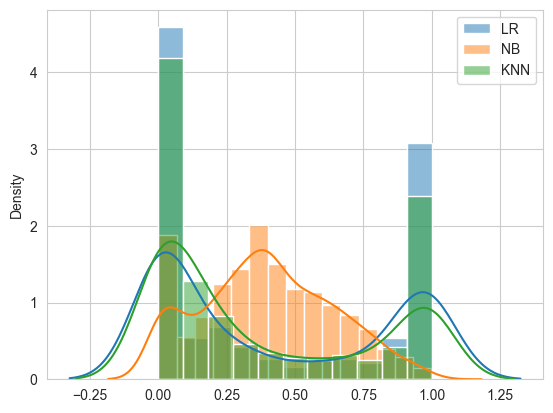

In [46]:
sns.histplot(lr_probs, kde=True, stat='density', kde_kws=dict(cut=3), label='LR')
sns.histplot(nb_probs, kde=True, stat='density', kde_kws=dict(cut=3), label='NB')
sns.histplot(knn_probs, kde=True, stat='density', kde_kws=dict(cut=3), label='KNN')
plt.legend()

The probabilities for all three classifiers are not calibrated.

Logistic regression and KNN exhibit similar distributions with two modes at the edges. This indicates that the classifiers are overly confident in their predictions, which might indicate overfitting.

Naive Bayes classifier, on the other, has one major peak in the middle of the ditribution, and a small peak around zero. The primary mode around 0.5 implies that the classifier is uncertain in its predictions, and requires more training.

#### Part 3

Show which classifier is the most overfitted according to development set (union of training and validation sets) and test set

Show which classifier is the least overfitted according to development set (union of training and validation sets) and test set

In [47]:
report = [
    {
        'model': 'LR',
        **quality_metrics(y_dev, best_lr.predict_proba(x_dev_ss)[:, 1], 'train'),
        **quality_metrics(y_test, lr_probs, 'test')
    },
    {
        'model': 'NB',
        **quality_metrics(y_dev, best_nb.predict_proba(x_dev_mms)[:, 1], 'train'),
        **quality_metrics(y_test, nb_probs, 'test')
    },
    {
        'model': 'KNN',
        **quality_metrics(y_dev, best_knn.predict_proba(x_dev_ss)[:, 1], 'train'),
        **quality_metrics(y_test, knn_probs, 'test')
    }
]
report = pd.DataFrame(report).set_index('model')
for metric in METRICS:
    report[f"diff_{metric}"] = report[f"train_{metric}"] - report[f"test_{metric}"]
report

,train_accuracy,train_roc_auc_score,train_f1_score,train_precision_score,train_recall_score,test_accuracy,test_roc_auc_score,test_f1_score,test_precision_score,test_recall_score,diff_accuracy,diff_roc_auc_score,diff_f1_score,diff_precision_score,diff_recall_score
model,,,,,,,,,,,,,,,
LR,0.933152,0.977076,0.915926,0.907859,0.924138,0.922910,0.970413,0.903664,0.890374,0.917355,0.010242,0.006663,0.012263,0.017485,0.006783
NB,0.897011,0.957457,0.858424,0.936430,0.792414,0.896851,0.962227,0.858841,0.932258,0.796143,0.000160,-0.004771,-0.000417,0.004172,-0.003729
KNN,0.999728,1.000000,0.999655,1.000000,0.999310,0.906623,0.973311,0.872781,0.942492,0.812672,0.093105,0.026689,0.126874,0.057508,0.186638


Overfitting is measured by the difference in quality of predictions between train and test datasets.

Clearly, KNN exhibits the most overfitting with the difference in F1-score exceeding 0.12. The least overfitted classifier, as noticed previously, is the Naive Bayes classifier, whose predictions on the test set appeared to be even better than the ones on the train set.

#### Part 4

Find 5 most and 5 least "spam" objects from the test data for every classifier.

Show which of them are matched and aren't matched.

In [48]:
print("LR most spam: ", np.argsort(lr_probs)[-5:])
print("LR least spam: ", np.argsort(lr_probs)[:5])
print('---------------------------------------')
print("NB most spam: ", np.argsort(nb_probs)[-5:])
print("NB least spam: ", np.argsort(nb_probs)[:5])
print('---------------------------------------')
print("KNN most spam: ", np.argsort(knn_probs)[-5:])
print("KNN least spam: ", np.argsort(knn_probs)[:5])

LR most spam:  [ 26 296 465 481 628]
LR least spam:  [199   8 236  17 524]
---------------------------------------
NB most spam:  [429 628  91 518  26]
NB least spam:  [199 524 435 103 879]
---------------------------------------
KNN most spam:  [804 806 510 847 697]
KNN least spam:  [920 349 348 764 339]


Interestingly, the sets are moslty different with only a few objects (199, 524, 26, 628) appearing multiple times.

According to Andrew Ng's book: https://github.com/yennlh/ml-yearning/blob/master/Ng_MLY01_13.pdf

We usually define:

• Training set​ — Which you run your learning algorithm on.

• Dev (development) set​ — Which you use to tune parameters, select features, and make other decisions regarding the learning algorithm. Sometimes also called the hold-out cross validation set​.

• Test set​ — which you use to evaluate the performance of the algorithm, but not to make any decisions regarding what learning algorithm or parameters to use.